# Estudio por simulación del efecto de los hiperparámetros de Random Forest en la clasificación de vinos

En este trabajo se estudia cómo cambian el desempeño predictivo, la estabilidad y el posible sobreajuste de un modelo Random Forest al modificar sus hiperparámetros principales. Para esto se utiliza un dataset de vinos blancos y tintos con variables físico-químicas, y se repite el entrenamiento del modelo muchas veces bajo distintas configuraciones.

## 1. Planteo del problema

El objetivo del estudio es analizar cómo influyen distintos hiperparámetros de Random Forest en la clasificación de vinos blancos y tintos. En particular, se busca estudiar si aumentar la cantidad de árboles, limitar la profundidad, modificar la cantidad de variables consideradas en cada división o cambiar el tamaño mínimo de hoja afecta el desempeño del modelo, la variabilidad de las métricas y la diferencia entre el rendimiento en entrenamiento y test.

**¿Cómo afectan los hiperparámetros principales de Random Forest al desempeño, la estabilidad y el sobreajuste en la clasificación de vinos?**

## 2. Modelización conceptual

| Elemento             | Definición en el trabajo                                        |
| -------------------- | --------------------------------------------------------------- |
| Unidad de análisis   | Cada vino del dataset                                           |
| Variables de entrada | Características físico-químicas del vino                        |
| Variable respuesta   | Tipo de vino: blanco o tinto                                    |
| Algoritmo            | Random Forest                                                   |
| Hiperparámetros      | `n_estimators`, `max_depth`, `max_features`, `min_samples_leaf` |
| Salidas del estudio  | Accuracy, F1-score, recall, AUC, error train-test, tiempo       |


## 3. Modelización probabilística

En este estudio, el azar aparece en distintos momentos del procedimiento:

- En la partición aleatoria entre conjunto de entrenamiento y conjunto de prueba.
- En la aleatoriedad interna del algoritmo Random Forest, ya que cada árbol se construye usando remuestreo y selección aleatoria de variables.
- En las múltiples réplicas de simulación, que permiten observar cómo varían las métricas bajo distintas particiones y configuraciones.
- En el análisis bootstrap posterior, utilizado para estimar el error estándar y el sesgo bootstrap de las métricas de desempeño.

Por lo tanto, en lugar de evaluar una única corrida del modelo, se repite el procedimiento muchas veces para cada configuración de hiperparámetros. Esto permite estudiar el desempeño promedio, la variabilidad y el posible sobreajuste del modelo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from time import perf_counter

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    roc_auc_score
)

# Configuración general
RANDOM_STATE = 42
TEST_SIZE = 0.30

DATA_PATH = Path("data/vinos.txt")
OUTPUTS_PATH = Path("outputs")
FIGURES_PATH = OUTPUTS_PATH / "figures"

OUTPUTS_PATH.mkdir(exist_ok=True)
FIGURES_PATH.mkdir(exist_ok=True)

In [3]:
df = pd.read_csv(DATA_PATH, sep="\t")

df.head()

,acidez_fija,acidez_volatil,acido_citrico,azucar_residual,cloruros,dioxido_azufre_libre,dioxido_azufre_total,densidad,pH,sulfatos,alcohol,vino
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,blanco
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,blanco
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,blanco
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,blanco
4,6.2,0.32,0.16,7.0,0.045,30.0,136.0,0.9949,3.18,0.47,9.6,blanco


In [4]:
print("Dimensiones del dataset:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)

print("\nValores faltantes:")
print(df.isna().sum())

print("\nDistribución de la variable respuesta:")
print(df["vino"].value_counts())

print("\nDistribución porcentual:")
print(df["vino"].value_counts(normalize=True).round(3))

Dimensiones del dataset: (5154, 12)

Tipos de datos:
acidez_fija             float64
acidez_volatil          float64
acido_citrico           float64
azucar_residual         float64
cloruros                float64
dioxido_azufre_libre    float64
dioxido_azufre_total    float64
densidad                float64
pH                      float64
sulfatos                float64
alcohol                 float64
vino                     object
dtype: object

Valores faltantes:
acidez_fija             0
acidez_volatil          0
acido_citrico           0
azucar_residual         0
cloruros                0
dioxido_azufre_libre    0
dioxido_azufre_total    0
densidad                0
pH                      0
sulfatos                0
alcohol                 0
vino                    0
dtype: int64

Distribución de la variable respuesta:
vino
blanco    3912
tinto     1242
Name: count, dtype: int64

Distribución porcentual:
vino
blanco    0.759
tinto     0.241
Name: proportion, dtype: float64


## 5. Preparación de los datos

In [5]:
# Copiamos el dataset para no modificar el original
datos = df.copy()

# Codificación de la variable respuesta
datos["vino_binario"] = datos["vino"].map({
    "blanco": 0,
    "tinto": 1
})

# Separación entre variables predictoras y variable respuesta
X = datos.drop(columns=["vino", "vino_binario"])
y = datos["vino_binario"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)
print("\nColumnas predictoras:")
print(X.columns.tolist())

print("\nDistribución de y:")
print(y.value_counts())

Dimensiones de X: (5154, 11)
Dimensiones de y: (5154,)

Columnas predictoras:
['acidez_fija', 'acidez_volatil', 'acido_citrico', 'azucar_residual', 'cloruros', 'dioxido_azufre_libre', 'dioxido_azufre_total', 'densidad', 'pH', 'sulfatos', 'alcohol']

Distribución de y:
vino_binario
0    3912
1    1242
Name: count, dtype: int64


In [6]:
assert X.shape[0] == y.shape[0]
assert y.isna().sum() == 0
assert X.isna().sum().sum() == 0
assert set(y.unique()) == {0, 1}

print("Chequeos iniciales correctos.")

Chequeos iniciales correctos.


## 6. Parámetros del estudio

A continuación se definen los parámetros generales del estudio de simulación.

Siguiendo la lógica de los ejercicios de simulación, se fija una configuración base del modelo y luego se modifican algunos hiperparámetros de a uno por vez. Para cada configuración se realizan varias réplicas, cambiando la partición entre entrenamiento y prueba y la semilla aleatoria del modelo.

Las métricas de interés serán:

- Accuracy en entrenamiento.
- Accuracy en prueba.
- Error de prueba, definido como \(1 - accuracy\).
- F1-score.
- Recall.
- AUC.
- Diferencia entre accuracy de entrenamiento y accuracy de prueba.
- Tiempo de entrenamiento.

In [7]:
from time import perf_counter

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score

# ============================================================
# Parámetros generales del estudio
# ============================================================

SEED = 123
TEST_SIZE = 0.30

# Primero usamos pocas réplicas para probar.
# Después, si corre bien, se puede subir a 100.
N_REPLICAS = 30

# Cantidad de réplicas bootstrap
B_BOOT = 1000

# Configuración base del Random Forest
params_base = {
    "n_estimators": 100,
    "max_depth": None,
    "max_features": "sqrt",
    "min_samples_leaf": 1
}

# Escenarios: modificamos un hiperparámetro por vez
escenarios = {
    "cantidad_arboles": {
        "hiperparametro": "n_estimators",
        "valores": [10, 50, 100, 300, 500]
    },
    "profundidad_maxima": {
        "hiperparametro": "max_depth",
        "valores": [2, 5, 10, None]
    },
    "variables_por_split": {
        "hiperparametro": "max_features",
        "valores": ["sqrt", "log2", None]
    },
    "minimo_muestras_hoja": {
        "hiperparametro": "min_samples_leaf",
        "valores": [1, 5, 10, 20]
    }
}

## 7. Funciones para estimar el modelo

En esta sección se definen funciones auxiliares para evitar repetir código. La idea es similar a los ejercicios anteriores: primero se define una función que ejecuta una réplica y luego se repite esa función muchas veces para cada escenario.

Cada réplica realiza los siguientes pasos:

1. Divide los datos en entrenamiento y prueba.
2. Entrena un Random Forest con una configuración determinada.
3. Calcula métricas en entrenamiento y prueba.
4. Guarda los resultados en un diccionario.

In [8]:
def calcular_metricas_clasificacion(modelo, X_train, X_test, y_train, y_test):
    """
    Calcula métricas de desempeño para clasificación binaria.

    La clase positiva es tinto = 1.
    """

    y_pred_train = modelo.predict(X_train)
    y_pred_test = modelo.predict(X_test)

    y_proba_test = modelo.predict_proba(X_test)[:, 1]

    accuracy_train = accuracy_score(y_train, y_pred_train)
    accuracy_test = accuracy_score(y_test, y_pred_test)

    f1 = f1_score(y_test, y_pred_test, pos_label=1)
    recall = recall_score(y_test, y_pred_test, pos_label=1)
    auc = roc_auc_score(y_test, y_proba_test)

    metricas = {
        "accuracy_train": accuracy_train,
        "accuracy_test": accuracy_test,
        "error_test": 1 - accuracy_test,
        "gap_accuracy": accuracy_train - accuracy_test,
        "f1_test": f1,
        "recall_test": recall,
        "auc_test": auc
    }

    return metricas

In [9]:
def correr_replica_rf(X, y, params_rf, replica, experimento, hiperparametro, valor_hiperparametro, orden_valor):
    """
    Ejecuta una réplica del estudio de simulación para Random Forest.
    """

    seed_replica = SEED + replica

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=seed_replica,
        stratify=y
    )

    modelo = RandomForestClassifier(
        **params_rf,
        random_state=seed_replica,
        n_jobs=-1
    )

    inicio = perf_counter()
    modelo.fit(X_train, y_train)
    fin = perf_counter()

    metricas = calcular_metricas_clasificacion(
        modelo=modelo,
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test
    )

    resultado = {
        "replica": replica,
        "experimento": experimento,
        "hiperparametro": hiperparametro,
        "valor_hiperparametro": str(valor_hiperparametro),
        "orden_valor": orden_valor,
        "tiempo_entrenamiento": fin - inicio
    }

    resultado.update(metricas)

    return resultado

## 8. Verificación y validación del programa

Antes de ejecutar el estudio completo, se realiza una prueba con una sola réplica. El objetivo no es todavía obtener conclusiones, sino verificar que el programa funciona correctamente y que las métricas calculadas tienen sentido.

In [10]:
resultado_prueba = correr_replica_rf(
    X=X,
    y=y,
    params_rf=params_base,
    replica=0,
    experimento="prueba",
    hiperparametro="configuracion_base",
    valor_hiperparametro="base",
    orden_valor=0
)

resultado_prueba

{'replica': 0,
 'experimento': 'prueba',
 'hiperparametro': 'configuracion_base',
 'valor_hiperparametro': 'base',
 'orden_valor': 0,
 'tiempo_entrenamiento': 0.1721079999115318,
 'accuracy_train': 0.9997227612974772,
 'accuracy_test': 0.9948287007110537,
 'error_test': 0.005171299288946329,
 'gap_accuracy': 0.004894060586423499,
 'f1_test': np.float64(0.9891891891891892),
 'recall_test': np.float64(0.9812332439678284),
 'auc_test': np.float64(0.9976661444798149)}

In [11]:
assert 0 <= resultado_prueba["accuracy_train"] <= 1
assert 0 <= resultado_prueba["accuracy_test"] <= 1
assert 0 <= resultado_prueba["error_test"] <= 1
assert 0 <= resultado_prueba["f1_test"] <= 1
assert 0 <= resultado_prueba["recall_test"] <= 1
assert 0 <= resultado_prueba["auc_test"] <= 1
assert resultado_prueba["tiempo_entrenamiento"] > 0

print("La réplica de prueba funciona correctamente.")

La réplica de prueba funciona correctamente.


## 9. Ejecución del estudio de simulación

Ahora se ejecuta el estudio completo. Para cada escenario se modifica un hiperparámetro de Random Forest, manteniendo constantes los demás valores de la configuración base.

Para cada valor del hiperparámetro se repite el procedimiento varias veces. Así se obtiene una distribución de métricas y no un único resultado aislado.

In [12]:
# ============================================================
# Ejecución del estudio completo
# ============================================================

resultados_simulacion = []

for nombre_experimento, info in escenarios.items():

    hiperparametro = info["hiperparametro"]
    valores = info["valores"]

    for orden_valor, valor in enumerate(valores):

        params_actuales = params_base.copy()
        params_actuales[hiperparametro] = valor

        print(f"Experimento: {nombre_experimento} | {hiperparametro} = {valor}")

        for replica in range(N_REPLICAS):

            resultado = correr_replica_rf(
                X=X,
                y=y,
                params_rf=params_actuales,
                replica=replica,
                experimento=nombre_experimento,
                hiperparametro=hiperparametro,
                valor_hiperparametro=valor,
                orden_valor=orden_valor
            )

            resultados_simulacion.append(resultado)

df_resultados = pd.DataFrame(resultados_simulacion)

df_resultados.head()

Experimento: cantidad_arboles | n_estimators = 10
Experimento: cantidad_arboles | n_estimators = 50
Experimento: cantidad_arboles | n_estimators = 100
Experimento: cantidad_arboles | n_estimators = 300
Experimento: cantidad_arboles | n_estimators = 500
Experimento: profundidad_maxima | max_depth = 2
Experimento: profundidad_maxima | max_depth = 5
Experimento: profundidad_maxima | max_depth = 10
Experimento: profundidad_maxima | max_depth = None
Experimento: variables_por_split | max_features = sqrt
Experimento: variables_por_split | max_features = log2
Experimento: variables_por_split | max_features = None
Experimento: minimo_muestras_hoja | min_samples_leaf = 1
Experimento: minimo_muestras_hoja | min_samples_leaf = 5
Experimento: minimo_muestras_hoja | min_samples_leaf = 10
Experimento: minimo_muestras_hoja | min_samples_leaf = 20


,replica,experimento,hiperparametro,valor_hiperparametro,orden_valor,tiempo_entrenamiento,accuracy_train,accuracy_test,error_test,gap_accuracy,f1_test,recall_test,auc_test
0,0,cantidad_arboles,n_estimators,10,0,0.032492,0.998891,0.989657,0.010343,0.009234,0.978261,0.965147,0.995371
1,1,cantidad_arboles,n_estimators,10,0,0.015771,0.999168,0.992889,0.007111,0.006279,0.985075,0.973190,0.997742
2,2,cantidad_arboles,n_estimators,10,0,0.024712,0.998891,0.992243,0.007757,0.006648,0.983740,0.973190,0.998081
3,3,cantidad_arboles,n_estimators,10,0,0.015842,0.998891,0.990950,0.009050,0.007941,0.981030,0.970509,0.994994
4,4,cantidad_arboles,n_estimators,10,0,0.015233,0.998337,0.990950,0.009050,0.007386,0.981030,0.970509,0.997810


In [13]:
print("Cantidad de filas generadas:", df_resultados.shape[0])
print("Cantidad de columnas:", df_resultados.shape[1])

df_resultados.to_csv("outputs/resultados_simulacion.csv", index=False)

print("Resultados guardados en outputs/resultados_simulacion.csv")

Cantidad de filas generadas: 480
Cantidad de columnas: 13
Resultados guardados en outputs/resultados_simulacion.csv


## 10. Visualización de resultados

En esta sección se construyen gráficos para comparar el comportamiento de Random Forest bajo las distintas configuraciones de hiperparámetros. Se analiza el error de prueba, la accuracy, el gap entre entrenamiento y prueba y el tiempo de entrenamiento.

In [24]:
def graficar_promedio_metrica(df, experimento, metrica, ylabel=None):
    """
    Grafica el promedio de una métrica para cada valor del hiperparámetro
    dentro de un experimento.
    """

    datos_exp = df[df["experimento"] == experimento].copy()

    resumen_exp = (
        datos_exp
        .groupby(["orden_valor", "valor_hiperparametro"])[metrica]
        .agg(["mean", "std"])
        .reset_index()
        .sort_values("orden_valor")
    )

    x = resumen_exp["valor_hiperparametro"].astype(str)
    y = resumen_exp["mean"]
    yerr = resumen_exp["std"]

    plt.figure(figsize=(8, 5))
    plt.errorbar(x, y, yerr=yerr, marker="o", capsize=4)
    plt.xlabel("Valor del hiperparámetro")
    plt.ylabel(ylabel if ylabel is not None else metrica)
    plt.title(f"{metrica} promedio - {experimento}")
    plt.grid(True)
    plt.show()

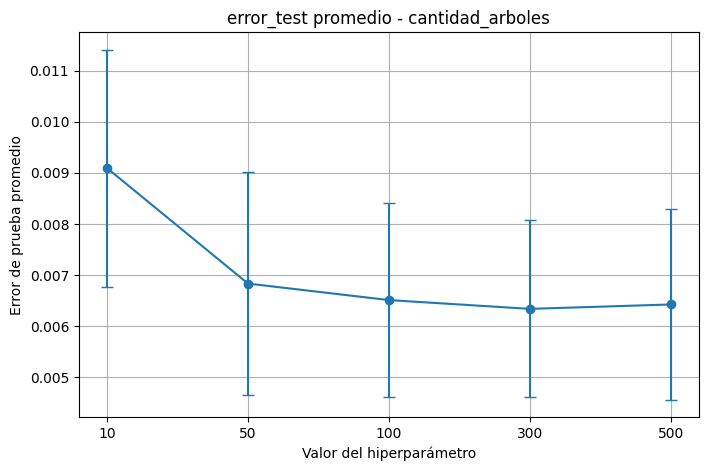

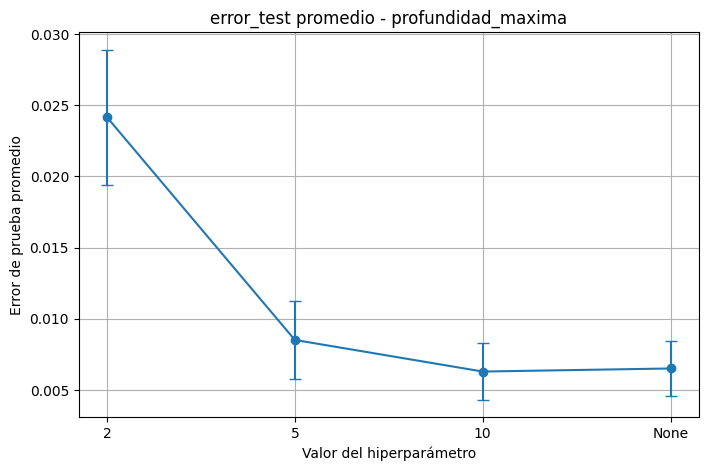

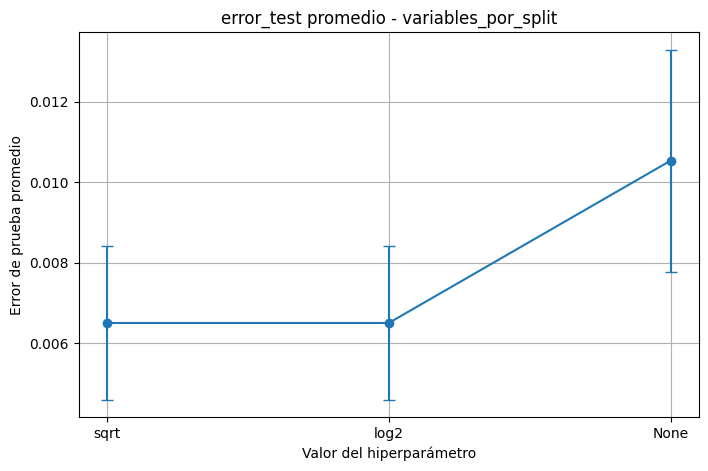

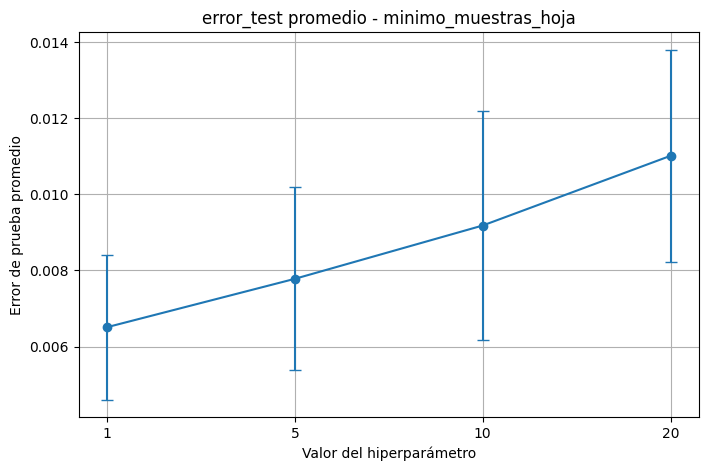

In [23]:
for experimento in df_resultados["experimento"].unique():
    graficar_promedio_metrica(
        df=df_resultados,
        experimento=experimento,
        metrica="error_test",
        ylabel="Error de prueba promedio"
    )

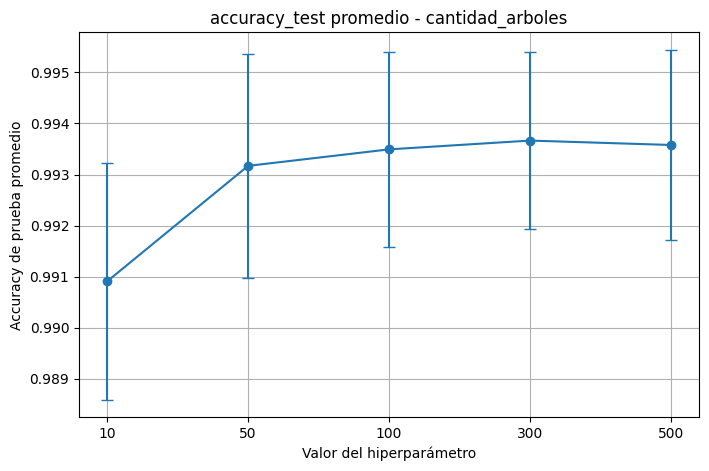

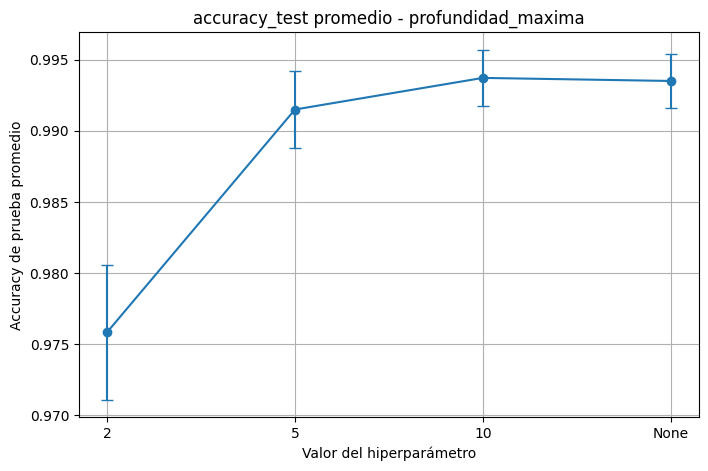

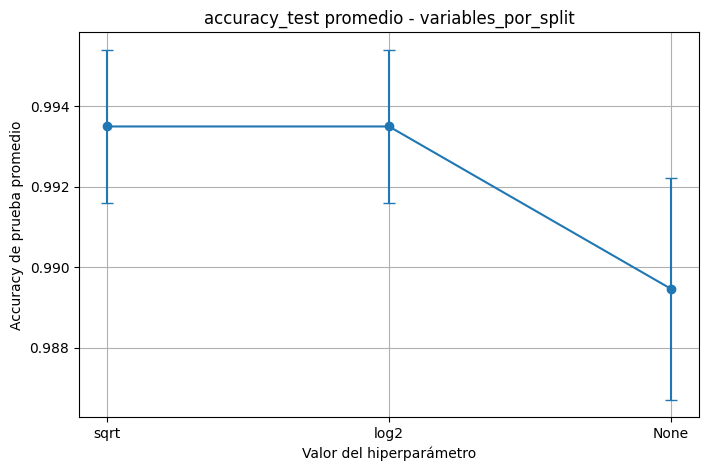

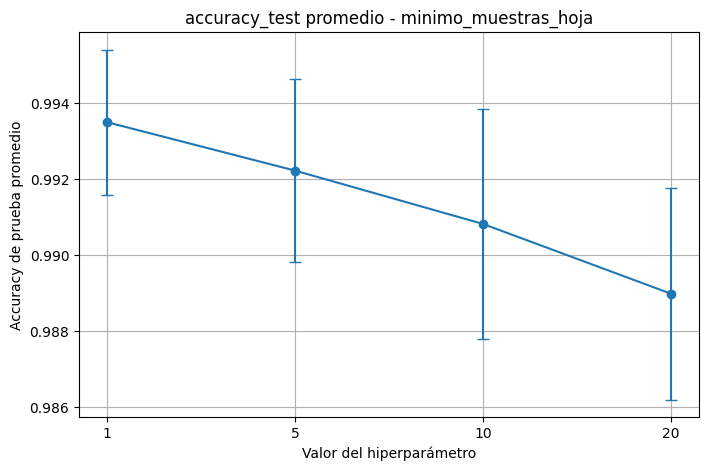

In [25]:
for experimento in df_resultados["experimento"].unique():
    graficar_promedio_metrica(
        df=df_resultados,
        experimento=experimento,
        metrica="accuracy_test",
        ylabel="Accuracy de prueba promedio"
    )

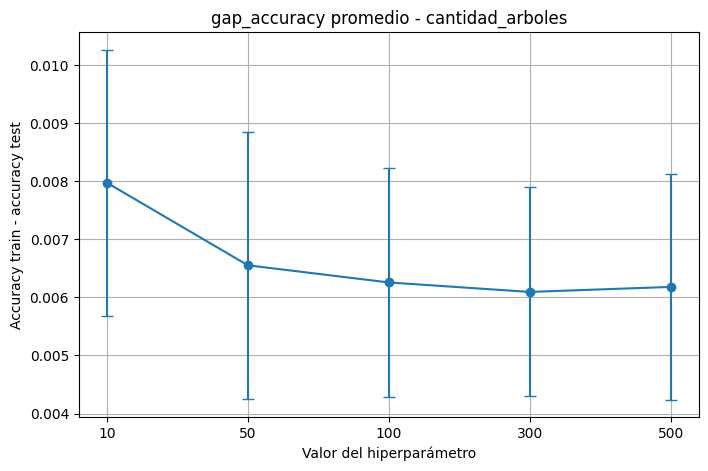

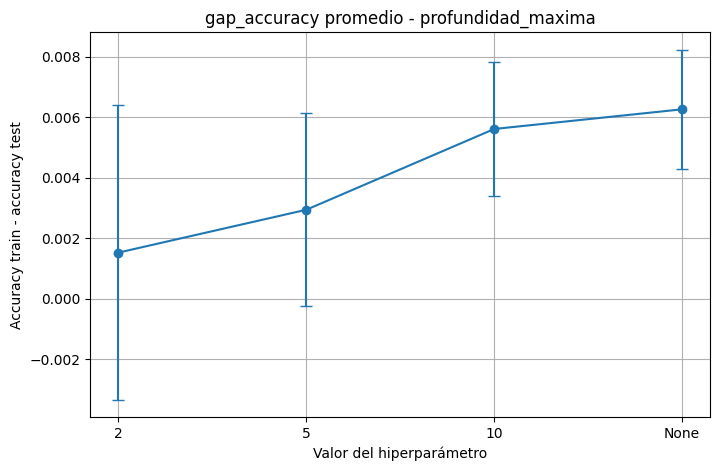

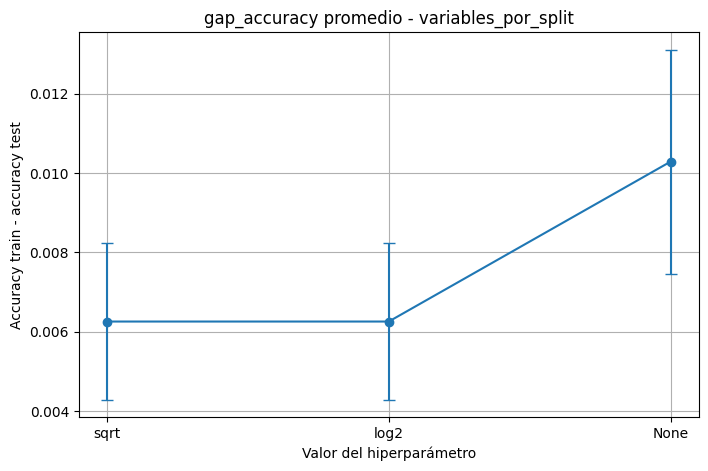

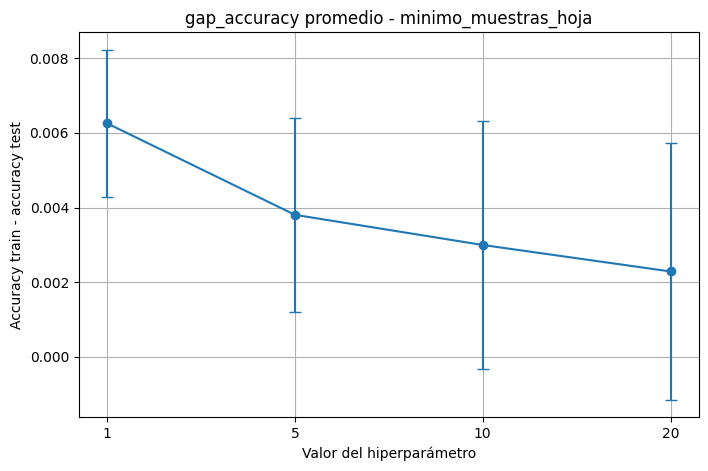

In [26]:
for experimento in df_resultados["experimento"].unique():
    graficar_promedio_metrica(
        df=df_resultados,
        experimento=experimento,
        metrica="gap_accuracy",
        ylabel="Accuracy train - accuracy test"
    )

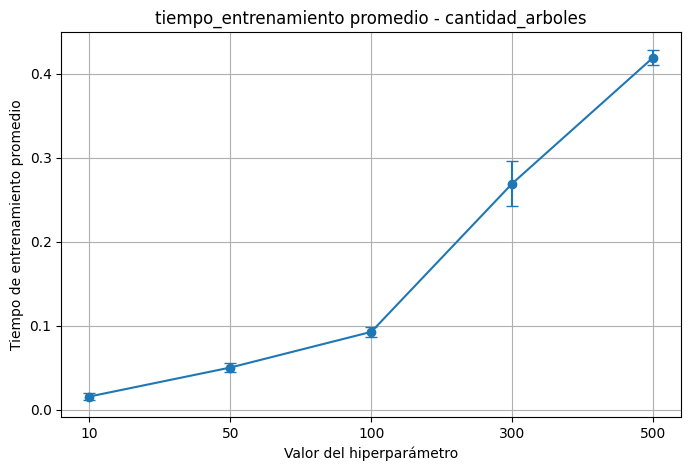

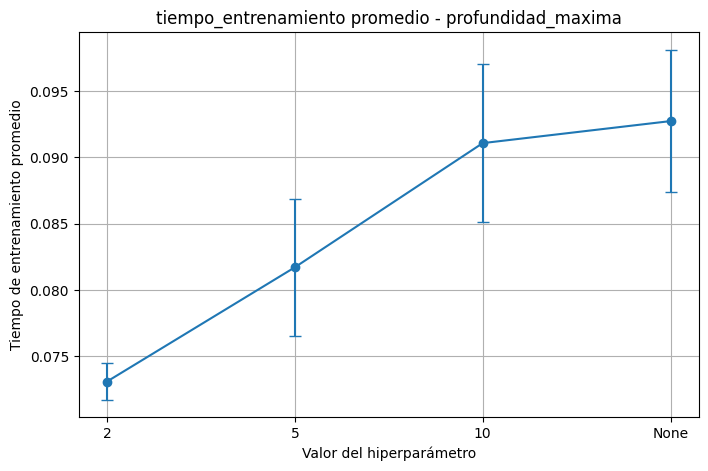

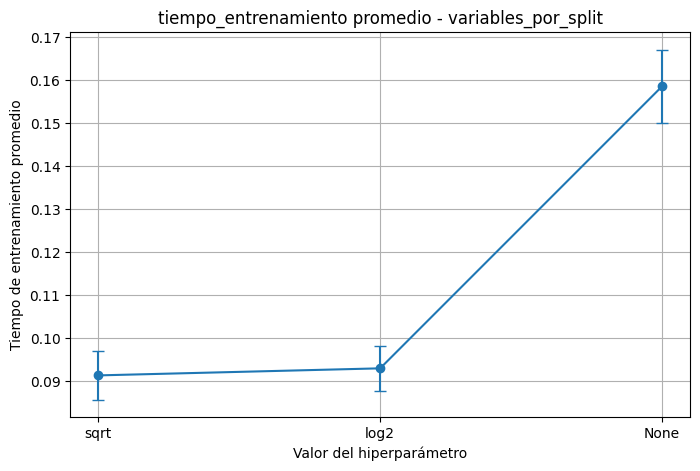

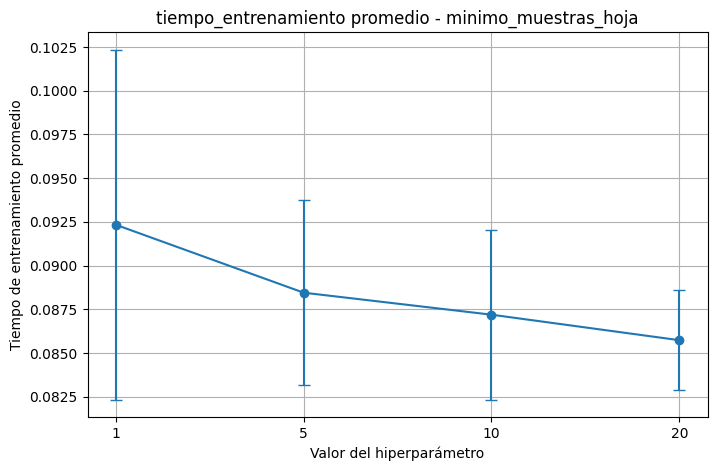

In [27]:
for experimento in df_resultados["experimento"].unique():
    graficar_promedio_metrica(
        df=df_resultados,
        experimento=experimento,
        metrica="tiempo_entrenamiento",
        ylabel="Tiempo de entrenamiento promedio"
    )

In [28]:
def boxplot_metrica(df, experimento, metrica, ylabel=None):
    """
    Realiza un boxplot de una métrica para cada valor del hiperparámetro.
    """

    datos_exp = df[df["experimento"] == experimento].copy()
    datos_exp = datos_exp.sort_values("orden_valor")

    valores_ordenados = (
        datos_exp[["orden_valor", "valor_hiperparametro"]]
        .drop_duplicates()
        .sort_values("orden_valor")
    )

    grupos = []
    etiquetas = []

    for _, fila in valores_ordenados.iterrows():
        valor = fila["valor_hiperparametro"]
        datos_valor = datos_exp[datos_exp["valor_hiperparametro"] == valor][metrica]
        grupos.append(datos_valor.values)
        etiquetas.append(str(valor))

    plt.figure(figsize=(8, 5))
    plt.boxplot(grupos, labels=etiquetas)
    plt.xlabel("Valor del hiperparámetro")
    plt.ylabel(ylabel if ylabel is not None else metrica)
    plt.title(f"Distribución de {metrica} - {experimento}")
    plt.grid(True)
    plt.show()

/var/folders/7p/7_8_rc5s5pl2sgvzk8fsscnr0000gp/T/ipykernel_66258/397905326.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(grupos, labels=etiquetas)


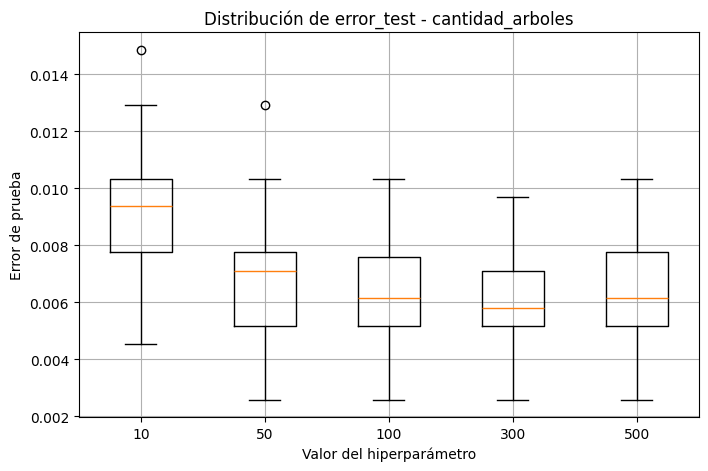

/var/folders/7p/7_8_rc5s5pl2sgvzk8fsscnr0000gp/T/ipykernel_66258/397905326.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(grupos, labels=etiquetas)


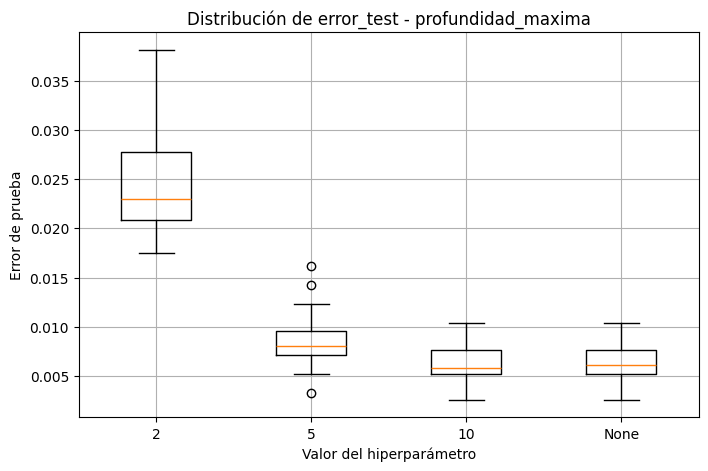

/var/folders/7p/7_8_rc5s5pl2sgvzk8fsscnr0000gp/T/ipykernel_66258/397905326.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(grupos, labels=etiquetas)


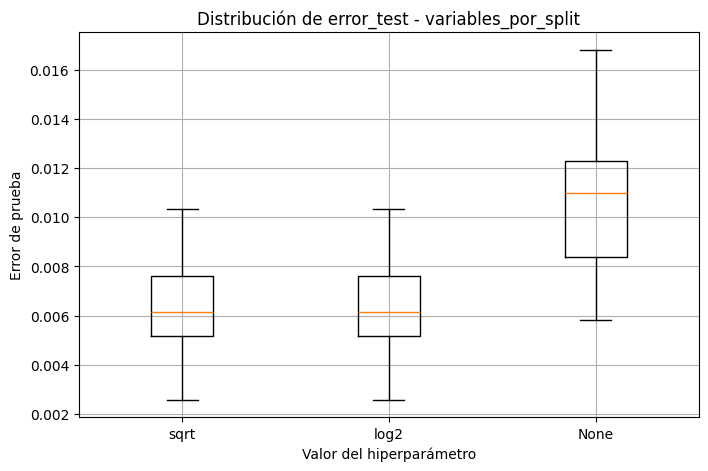

/var/folders/7p/7_8_rc5s5pl2sgvzk8fsscnr0000gp/T/ipykernel_66258/397905326.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(grupos, labels=etiquetas)


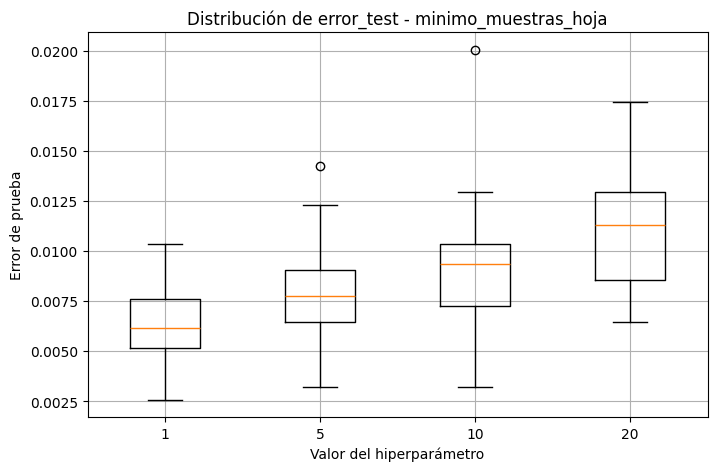

In [29]:
for experimento in df_resultados["experimento"].unique():
    boxplot_metrica(
        df=df_resultados,
        experimento=experimento,
        metrica="error_test",
        ylabel="Error de prueba"
    )

## 10. Métricas resumen

In [14]:
metricas_interes = [
    "accuracy_train",
    "accuracy_test",
    "error_test",
    "gap_accuracy",
    "f1_test",
    "recall_test",
    "auc_test",
    "tiempo_entrenamiento"
]

tabla_resumen = (
    df_resultados
    .groupby(["experimento", "hiperparametro", "valor_hiperparametro"])[metricas_interes]
    .agg(["mean", "std"])
    .round(4)
)

tabla_resumen

accuracy_train  \
                                                                     mean   
experimento          hiperparametro   valor_hiperparametro                  
cantidad_arboles     n_estimators     10                           0.9989   
                                      100                          0.9998   
                                      300                          0.9998   
                                      50                           0.9997   
                                      500                          0.9998   
minimo_muestras_hoja min_samples_leaf 1                            0.9998   
                                      10                           0.9938   
                                      20                           0.9913   
                                      5                            0.9960   
profundidad_maxima   max_depth        10                           0.9993   
                                      2                            0.9774   
                                      5                            0.9944   
                                      None                         0.9998   
variables_por_split  max_features     None                         0.9998   
                                      log2                         0.9998   
                                      sqrt                         0.9998   

                                                                    \
                                                               std   
experimento          hiperparametro   valor_hiperparametro           
cantidad_arboles     n_estimators     10                    0.0004   
                                      100                   0.0002   
                                      300                   0.0002   
                                      50                    0.0002   
                                      500                   0.0002   
minimo_muestras_hoja min_samples_leaf 1                     0.0002   
                                      10                    0.0008   
                                      20                    0.0009   
                                      5                     0.0005   
profundidad_maxima   max_depth        10                    0.0004   
                                      2                     0.0025   
                                      5                     0.0007   
                                      None                  0.0002   
variables_por_split  max_features     None                  0.0002   
                                      log2                  0.0002   
                                      sqrt                  0.0002   

                                                           accuracy_test  \
                                                                    mean   
experimento          hiperparametro   valor_hiperparametro                 
cantidad_arboles     n_estimators     10                          0.9909   
                                      100                         0.9935   
                                      300                         0.9937   
                                      50                          0.9932   
                                      500                         0.9936   
minimo_muestras_hoja min_samples_leaf 1                           0.9935   
                                      10                          0.9908   
                                      20                          0.9890   
                                      5                           0.9922   
profundidad_maxima   max_depth        10                          0.9937   
                                      2                           0.9758   
                                      5                           0.9915   
                                      None                        0.9935   
variables_por_split  max_features     None      

In [15]:
tabla_resumen.to_csv("outputs/tabla_resumen_simulacion.csv")

## 11. Bootstrap sobre las métricas de desempeño

Luego de obtener las réplicas de simulación, se aplica bootstrap sobre las métricas obtenidas para cada configuración.

Para una métrica cualquiera, se calcula:

- La estimación original: promedio de la métrica en las réplicas.
- El error estándar bootstrap: desvío estándar de las réplicas bootstrap.
- El sesgo bootstrap: diferencia entre el promedio bootstrap y la estimación original.
- El ratio \(|sesgo| / SE\), usado para evaluar si el sesgo bootstrap es relevante.

En este caso, el sesgo calculado no es el sesgo teórico del modelo respecto de una función verdadera desconocida, sino el sesgo bootstrap de la métrica estimada.

In [16]:
def bootstrap_media_metrica(valores, B, rng):
    """
    Genera B réplicas bootstrap de la media de una métrica.

    valores: array con las métricas obtenidas en las réplicas de simulación.
    B: cantidad de réplicas bootstrap.
    rng: instancia de np.random.default_rng().
    """

    valores = np.asarray(valores)
    n = len(valores)

    replicas_bootstrap = np.empty(B)

    for b in range(B):
        muestra_bootstrap = rng.choice(valores, size=n, replace=True)
        replicas_bootstrap[b] = np.mean(muestra_bootstrap)

    return replicas_bootstrap

In [17]:
metricas_bootstrap = [
    "accuracy_test",
    "error_test",
    "f1_test",
    "recall_test",
    "auc_test",
    "gap_accuracy"
]

filas_bootstrap = []

rng_boot = np.random.default_rng(SEED)

for (experimento, hiperparametro, valor), datos_grupo in df_resultados.groupby(
    ["experimento", "hiperparametro", "valor_hiperparametro"]
):

    for metrica in metricas_bootstrap:

        valores = datos_grupo[metrica].values

        estimacion_original = np.mean(valores)

        replicas_boot = bootstrap_media_metrica(
            valores=valores,
            B=B_BOOT,
            rng=rng_boot
        )

        se_boot = np.std(replicas_boot, ddof=1)
        sesgo_boot = np.mean(replicas_boot) - estimacion_original

        if se_boot != 0:
            ratio = abs(sesgo_boot) / se_boot
        else:
            ratio = np.nan

        filas_bootstrap.append({
            "experimento": experimento,
            "hiperparametro": hiperparametro,
            "valor_hiperparametro": valor,
            "metrica": metrica,
            "estimacion_original": estimacion_original,
            "SE_bootstrap": se_boot,
            "sesgo_bootstrap": sesgo_boot,
            "|sesgo|/SE": ratio
        })

df_bootstrap = pd.DataFrame(filas_bootstrap)

df_bootstrap.head()

,experimento,hiperparametro,valor_hiperparametro,metrica,estimacion_original,SE_bootstrap,sesgo_bootstrap,|sesgo|/SE
0,cantidad_arboles,n_estimators,10,accuracy_test,0.990907,0.000428,0.000004,0.008360
1,cantidad_arboles,n_estimators,10,error_test,0.009093,0.000423,0.000011,0.026825
2,cantidad_arboles,n_estimators,10,f1_test,0.980908,0.000878,0.000025,0.028849
3,cantidad_arboles,n_estimators,10,recall_test,0.969705,0.001692,0.000022,0.012834
4,cantidad_arboles,n_estimators,10,auc_test,0.996247,0.000345,0.000013,0.038328


In [18]:
df_bootstrap.to_csv("outputs/resultados_bootstrap.csv", index=False)

df_bootstrap.round(5)

,experimento,hiperparametro,valor_hiperparametro,metrica,estimacion_original,SE_bootstrap,sesgo_bootstrap,|sesgo|/SE
0,cantidad_arboles,n_estimators,10,accuracy_test,0.99091,0.00043,0.00000,0.00836
1,cantidad_arboles,n_estimators,10,error_test,0.00909,0.00042,0.00001,0.02682
2,cantidad_arboles,n_estimators,10,f1_test,0.98091,0.00088,0.00003,0.02885
3,cantidad_arboles,n_estimators,10,recall_test,0.96971,0.00169,0.00002,0.01283
4,cantidad_arboles,n_estimators,10,auc_test,0.99625,0.00034,0.00001,0.03833
...,...,...,...,...,...,...,...,...
91,variables_por_split,max_features,sqrt,error_test,0.00651,0.00034,0.00001,0.02066
92,variables_por_split,max_features,sqrt,f1_test,0.98639,0.00071,-0.00000,0.00268
93,variables_por_split,max_features,sqrt,recall_test,0.97900,0.00133,-0.00002,0.01801
94,variables_por_split,max_features,sqrt,auc_test,0.99758,0.00029,-0.00001,0.02132


In [19]:
df_bootstrap["sesgo_relevante"] = np.where(
    df_bootstrap["|sesgo|/SE"] >= 0.25,
    "Sí",
    "No"
)

df_bootstrap.round(5).head(20)

,experimento,hiperparametro,valor_hiperparametro,metrica,estimacion_original,SE_bootstrap,sesgo_bootstrap,|sesgo|/SE,sesgo_relevante
0,cantidad_arboles,n_estimators,10,accuracy_test,0.99091,0.00043,0.00000,0.00836,No
1,cantidad_arboles,n_estimators,10,error_test,0.00909,0.00042,0.00001,0.02682,No
2,cantidad_arboles,n_estimators,10,f1_test,0.98091,0.00088,0.00003,0.02885,No
3,cantidad_arboles,n_estimators,10,recall_test,0.96971,0.00169,0.00002,0.01283,No
4,cantidad_arboles,n_estimators,10,auc_test,0.99625,0.00034,0.00001,0.03833,No
5,cantidad_arboles,n_estimators,10,gap_accuracy,0.00797,0.00041,0.00000,0.00378,No
6,cantidad_arboles,n_estimators,100,accuracy_test,0.99349,0.00035,0.00002,0.05910,No
7,cantidad_arboles,n_estimators,100,error_test,0.00651,0.00034,0.00000,0.00158,No
8,cantidad_arboles,n_estimators,100,f1_test,0.98639,0.00073,0.00002,0.03337,No
9,cantidad_arboles,n_estimators,100,recall_test,0.97900,0.00133,0.00003,0.01992,No


## 12. Visualización del error estándar y sesgo bootstrap

En esta sección se visualizan los resultados del análisis bootstrap. Para cada configuración de hiperparámetros se grafica:

- El error estándar bootstrap de la media del error de prueba.
- El sesgo bootstrap de la media del error de prueba.
- El cociente entre el valor absoluto del sesgo y el error estándar.

Este último indicador permite evaluar si el sesgo bootstrap es relevante en comparación con la variabilidad de la estimación.

In [30]:
# Recuperamos el orden de los valores de cada hiperparámetro
orden_valores = (
    df_resultados[["experimento", "hiperparametro", "valor_hiperparametro", "orden_valor"]]
    .drop_duplicates()
)

df_bootstrap = df_bootstrap.merge(
    orden_valores,
    on=["experimento", "hiperparametro", "valor_hiperparametro"],
    how="left"
)

df_bootstrap.head()

,experimento,hiperparametro,valor_hiperparametro,metrica,estimacion_original,SE_bootstrap,sesgo_bootstrap,|sesgo|/SE,sesgo_relevante,orden_valor
0,cantidad_arboles,n_estimators,10,accuracy_test,0.990907,0.000428,0.000004,0.008360,No,0
1,cantidad_arboles,n_estimators,10,error_test,0.009093,0.000423,0.000011,0.026825,No,0
2,cantidad_arboles,n_estimators,10,f1_test,0.980908,0.000878,0.000025,0.028849,No,0
3,cantidad_arboles,n_estimators,10,recall_test,0.969705,0.001692,0.000022,0.012834,No,0
4,cantidad_arboles,n_estimators,10,auc_test,0.996247,0.000345,0.000013,0.038328,No,0


In [31]:
def graficar_bootstrap(df_bootstrap, experimento, metrica="error_test"):
    """
    Grafica error estándar bootstrap, sesgo bootstrap y ratio |sesgo|/SE
    para una métrica dentro de un experimento.
    """

    datos = df_bootstrap[
        (df_bootstrap["experimento"] == experimento) &
        (df_bootstrap["metrica"] == metrica)
    ].copy()

    datos = datos.sort_values("orden_valor")

    x = datos["valor_hiperparametro"].astype(str)

    # Gráfico 1: Error estándar bootstrap
    plt.figure(figsize=(8, 5))
    plt.bar(x, datos["SE_bootstrap"])
    plt.xlabel("Valor del hiperparámetro")
    plt.ylabel("Error estándar bootstrap")
    plt.title(f"Error estándar bootstrap de {metrica} - {experimento}")
    plt.grid(axis="y")
    plt.show()

    # Gráfico 2: Sesgo bootstrap
    plt.figure(figsize=(8, 5))
    plt.bar(x, datos["sesgo_bootstrap"])
    plt.axhline(0, linestyle="--")
    plt.xlabel("Valor del hiperparámetro")
    plt.ylabel("Sesgo bootstrap")
    plt.title(f"Sesgo bootstrap de {metrica} - {experimento}")
    plt.grid(axis="y")
    plt.show()

    # Gráfico 3: Ratio |sesgo| / SE
    plt.figure(figsize=(8, 5))
    plt.bar(x, datos["|sesgo|/SE"])
    plt.axhline(0.25, linestyle="--", label="Umbral 0.25")
    plt.xlabel("Valor del hiperparámetro")
    plt.ylabel("|sesgo| / SE")
    plt.title(f"Importancia relativa del sesgo bootstrap - {experimento}")
    plt.legend()
    plt.grid(axis="y")
    plt.show()

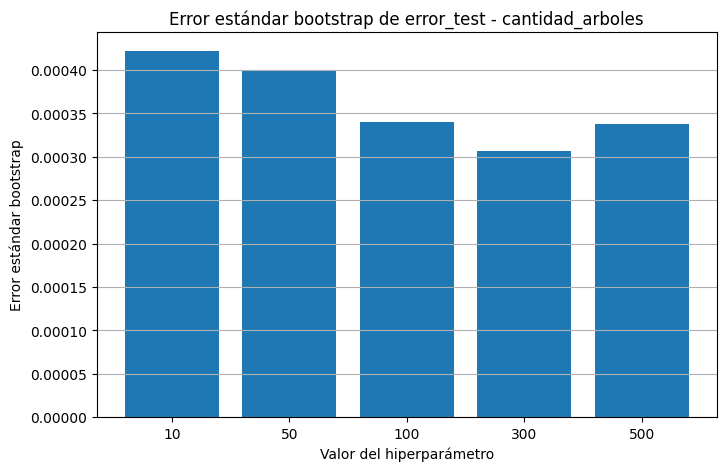

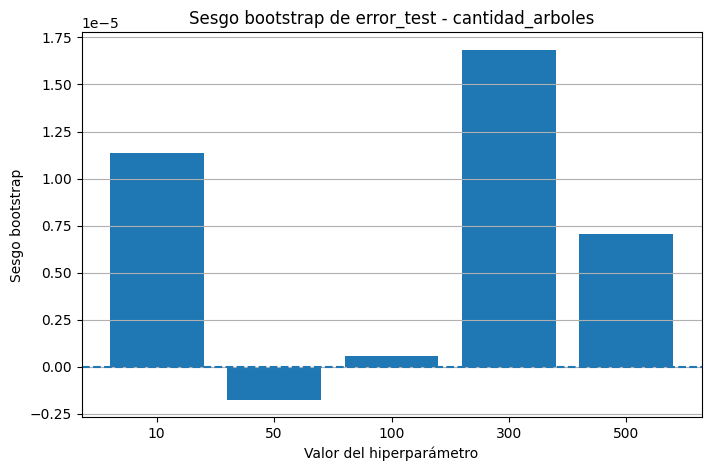

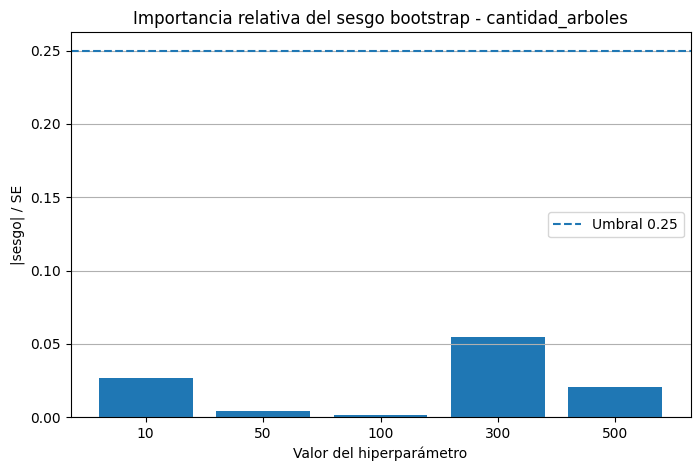

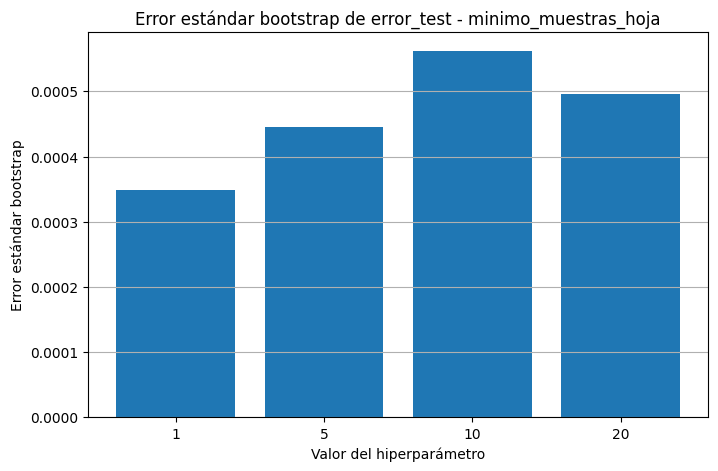

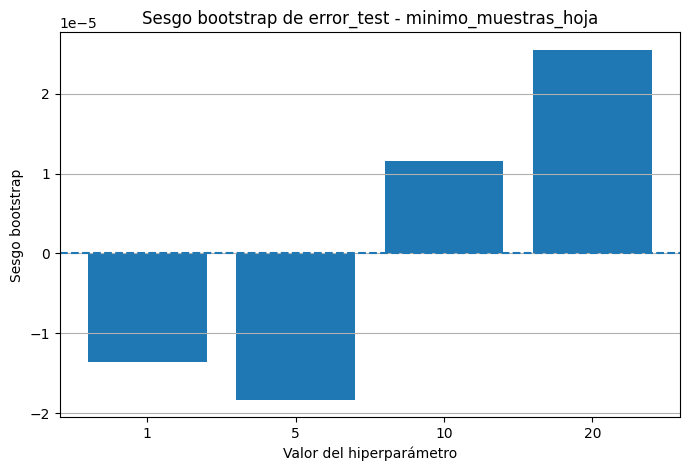

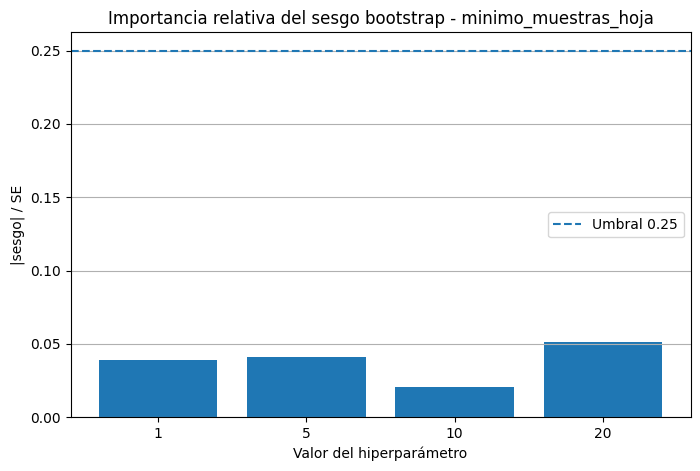

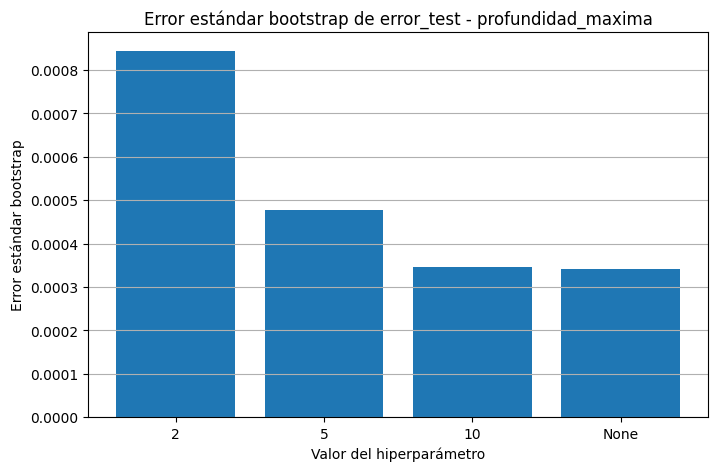

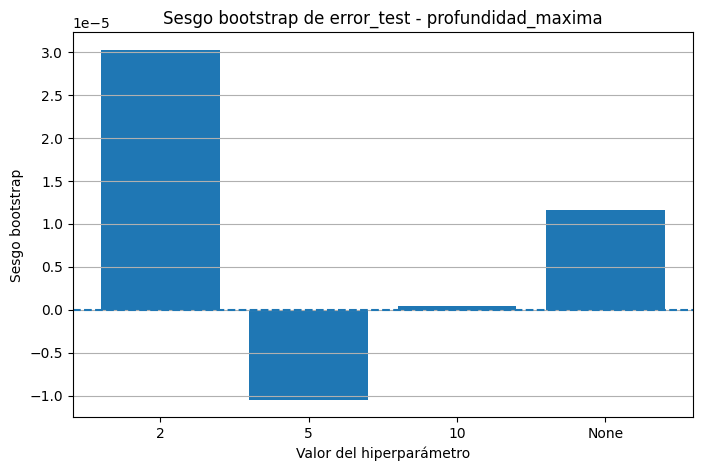

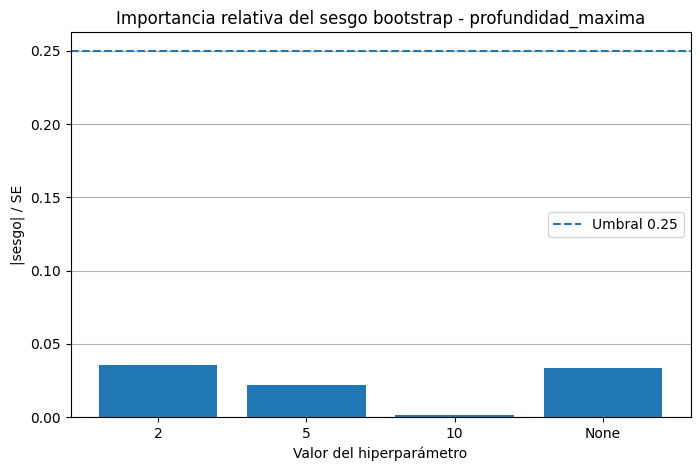

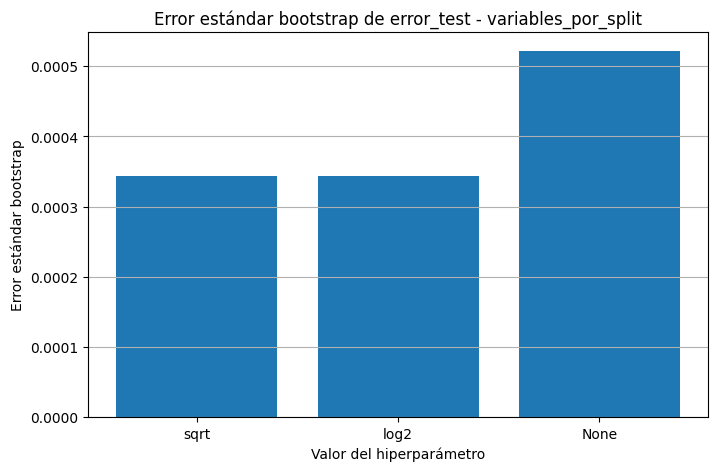

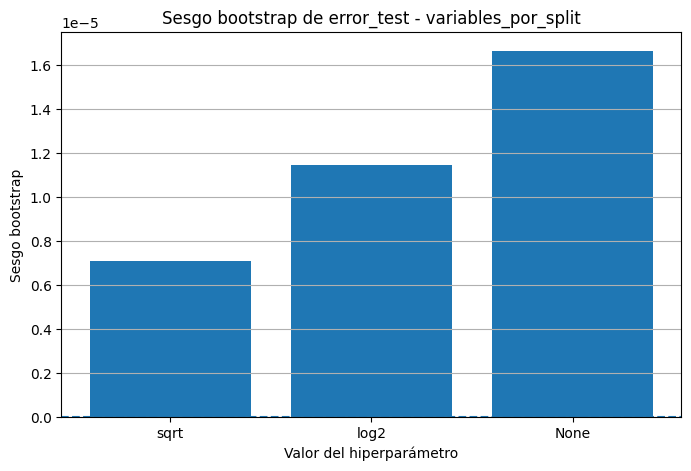

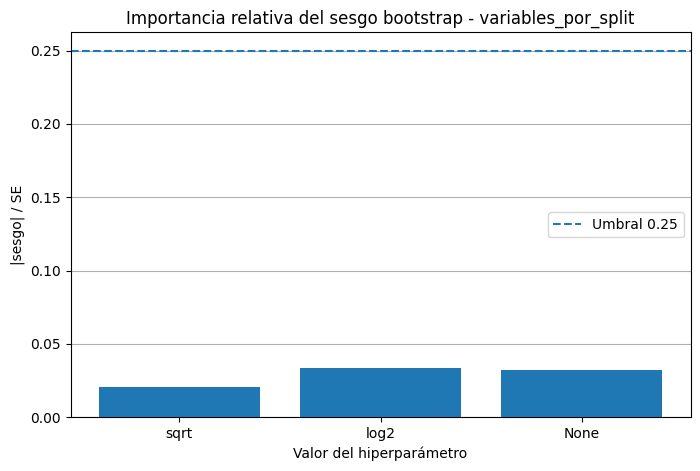

In [32]:
for experimento in df_bootstrap["experimento"].unique():
    graficar_bootstrap(
        df_bootstrap=df_bootstrap,
        experimento=experimento,
        metrica="error_test"
    )